# 06 · Optuna con validación temporal

Este es el notebook principal para **leer el código, examinar datos, entrenar y
seguir los resultados** del nuevo experimento. Las funciones de partición,
selección, búsqueda y evaluación aparecen aquí como celdas ejecutables.

**Estado inicial:** el entrenamiento en segundo plano usa los mismos estudios.
`EJECUTAR_ENTRENAMIENTO=False` permite ejecutar todo el notebook para revisar el
trabajo sin lanzar una segunda búsqueda. La celda de entrenamiento incluye un
bloqueo para impedir dos procesos modificando a la vez los mismos estudios.

Para continuar aquí: crear `reports/optuna_temporal_v1/STOP`, esperar que termine
el trial activo, retirar ese archivo y activar `EJECUTAR_ENTRENAMIENTO=True`.
No se pierden los trials ya completados. Mantener el kernel activo durante la búsqueda.

No se ha demostrado un techo teórico del modelo. Este experimento mide el
rendimiento temporal sobre variables transaccionales y no promete una mejora.

## 1. Entorno y configuración

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Abrir este notebook dentro del repositorio")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
PROC = ROOT / "data/processed"

In [2]:
import hashlib
import time
import ast
import fcntl
import importlib.metadata
import joblib
import optuna
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, recall_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Estas dos clases residen en un módulo importable para poder recargar los .joblib
# fuera de Jupyter. El resto de las funciones de entrenamiento se define abajo.
from scripts.temporal_optuna import TransactionFeatures, KeepColumns

ID = ["id_vendedor", "mes_obs", "mes_rank"]
META = ID + ["churn"]
MASTER = ["sexo", "edad", "antiguedad_meses", "tipo_vendedor", "departamento", "provincia"]
ZERO = ["tend_monto_u3_vs_prev3", "tend_nped_u3_vs_prev3", "monto_cv_u12",
        "monto_ult_vs_media", "monto_por_prod_acum"] + [
    f"d_{m}_m{n}" for m in ("monto", "nped") for n in (1, 3, 6, 9, 12)]
MODELS = ["logreg", "rf", "xgboost", "catboost"]

OUT = ROOT / "reports/optuna_temporal_v1"
N_TRIALS = 100                 # total por modelo, incluyendo trials existentes
THREADS = 4
EJECUTAR_ENTRENAMIENTO = False # True para entrenar desde este notebook

## 2. Datos y validación de integridad

Partimos del original, **no del CSV con 68 variables seleccionadas globalmente**.
Se excluyen IDs, target y datos maestros para evitar información de snapshots
históricos no garantizados. Los nulos estructurales conocidos se imputan a cero;
cualquier texto numérico inválido o infinito produce un error.

In [3]:
def digest(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def write_json(path, value):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(value, indent=2, ensure_ascii=False, default=str) + "\n")
    tmp.replace(path)

def check_numeric(frame):
    if any(not pd.api.types.is_numeric_dtype(t) for t in frame.dtypes):
        raise ValueError("Non-numeric feature detected; refusing silent coercion")
    if not np.isfinite(frame.to_numpy(dtype=float)).all():
        raise ValueError("Missing or infinite feature detected")

def engineer(df):
    d = df.copy()

    def ratio(a, b):
        return (a / b.replace(0, np.nan)).fillna(0)

    d["ticket_prom_u12"] = ratio(d.monto_u12, d.n_ped_u12)
    d["ticket_prom_u3"] = ratio(d.monto_u3, d.n_ped_u3)
    d["intensidad_u3"] = ratio(d.n_ped_u3, d.meses_activos_u3)
    d["basket_size_u12"] = ratio(d.n_prod_u12, d.n_ped_u12)
    d["recencia_norm"] = d.meses_desde_compra_previa * d.meses_activos_u12 / 12
    d["tasa_act_reciente_vs_hist"] = ratio(d.meses_activos_u3 / 3, d.meses_activos_u12 / 12)
    return d

def load_raw():
    df = pd.read_csv(PROC / "churn_dataset.csv", parse_dates=["mes_obs"])
    if df.duplicated(["id_vendedor", "mes_rank"]).any() or df[META].isna().any().any():
        raise ValueError("Invalid dataset keys")
    if set(df.churn.unique()) != {0, 1}:
        raise ValueError("Invalid target")
    ordinal = df.mes_obs.dt.year * 12 + df.mes_obs.dt.month
    if (ordinal - df.mes_rank).nunique() != 1:
        raise ValueError("mes_rank is not aligned to calendar months")
    # Only structurally missing transactional features may be filled with zero.
    transactional = df.drop(columns=META + MASTER).copy()
    transactional[ZERO] = transactional[ZERO].fillna(0)
    check_numeric(transactional)
    return df

In [4]:
raw = load_raw()
oot_start = int(raw.mes_rank.max()) - 3
train = raw[raw.mes_rank <= oot_start - 7].reset_index(drop=True)
pd.DataFrame({"conjunto": ["dataset original", "pool de desarrollo"],
              "filas": [len(raw), len(train)],
              "inicio": [raw.mes_obs.min(), train.mes_obs.min()],
              "fin": [raw.mes_obs.max(), train.mes_obs.max()]})

,conjunto,filas,inicio,fin
0,dataset original,30356,2016-12-01,2025-11-01
1,pool de desarrollo,28311,2016-12-01,2025-01-01


### Transformaciones persistibles

`TransactionFeatures` elimina columnas no transaccionales, imputa únicamente
nulos estructurales, añade las seis razones y valida tipos. `KeepColumns` conserva
la selección. Se importan desde el módulo para que los pipelines guardados puedan
abrirse en otro proceso. Esta celda muestra exactamente sus implementaciones:

In [5]:
import inspect
print(inspect.getsource(TransactionFeatures))
print(inspect.getsource(KeepColumns))

class TransactionFeatures(TransformerMixin, BaseEstimator):
    """Deterministic transaction-only features; no snapshot master data."""

    def fit(self, X, y=None):
        self.columns_ = self._convert(X).columns.tolist()
        return self

    def _convert(self, X):
        d = X.drop(columns=META + MASTER, errors="ignore").copy()
        d[ZERO] = d[ZERO].fillna(0)
        check_numeric(d)
        d = engineer(d)
        check_numeric(d)
        return d

    def transform(self, X):
        d = self._convert(X)
        if d.columns.tolist() != self.columns_:
            raise ValueError("Feature schema changed")
        return d

class KeepColumns(TransformerMixin, BaseEstimator):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.columns]



## 3. Particiones temporales y selección interna

Validación exterior: cuatro bloques de cuatro meses (octubre de 2023–enero de 2025).
Cada entrenamiento termina **siete ranks antes del primer mes de validación**:
así quedan seis meses de gap y las etiquetas de entrenamiento ya están disponibles.

Selección: dentro de cada entrenamiento se reserva otro bloque temporal de cuatro
meses con el mismo gap. Un bosque se ajusta en su pasado y se calcula importancia
por permutación **AUC** en ese bloque interno. Optuna compara esa selección con
todas las variables. La validación exterior nunca selecciona directamente variables.

Las importancias positivas son una heurística, no significancia estadística.
El OOT histórico y su gap no participan en esta búsqueda.

In [6]:
def temporal_folds(df, n_folds=4, months=4, gap=6):
    last = int(df.mes_rank.max())
    folds = []
    for i in range(n_folds):
        end = last - months * (n_folds - 1 - i)
        start = end - months + 1
        tr = np.flatnonzero(df.mes_rank.to_numpy() <= start - gap - 1)
        va = np.flatnonzero(df.mes_rank.between(start, end).to_numpy())
        if len(tr) < 100 or len(va) < 40:
            raise ValueError("Insufficient rows for temporal split")
        if df.iloc[tr].churn.nunique() != 2 or df.iloc[va].churn.nunique() != 2:
            raise ValueError("Both target classes required in each partition")
        if int(df.iloc[tr].mes_rank.max()) + gap >= int(df.iloc[va].mes_rank.min()):
            raise ValueError("Temporal label overlap")
        folds.append((tr, va))
    return folds

def select_inside_training(train, threads):
    """Permutation AUC on an inner temporal split, never on the objective validation."""
    tr, va = temporal_folds(train, n_folds=1)[0]
    transform = TransactionFeatures().fit(train.iloc[tr])
    a, b = transform.transform(train.iloc[tr]), transform.transform(train.iloc[va])
    model = RandomForestClassifier(n_estimators=150, max_depth=8, min_samples_leaf=20,
                                   class_weight="balanced", n_jobs=threads, random_state=42)
    model.fit(a, train.iloc[tr].churn)
    imp = permutation_importance(model, b, train.iloc[va].churn,
                                 scoring="roc_auc", n_repeats=3, n_jobs=1, random_state=42)
    selected = a.columns[imp.importances_mean > 0].tolist()
    if not selected:
        selected = a.columns.tolist()
    return selected, dict(zip(a.columns, imp.importances_mean.tolist()))

def prepare(df, threads):
    result = []
    for i, (tr, va) in enumerate(temporal_folds(df)):
        train, valid = df.iloc[tr], df.iloc[va]
        selector, importance = select_inside_training(train, threads)
        transformer = TransactionFeatures().fit(train)
        info = {"fold": i, "train_rows": len(tr), "valid_rows": len(va),
                "train_end": str(train.mes_obs.max().date()),
                "valid_start": str(valid.mes_obs.min().date()),
                "valid_end": str(valid.mes_obs.max().date()),
                "selected": selector, "inner_permutation_auc": importance}
        result.append({"X_train": transformer.transform(train), "y_train": train.churn.to_numpy(),
                       "X_valid": transformer.transform(valid), "y_valid": valid.churn.to_numpy(),
                       "valid_months": valid.mes_obs.astype(str).to_numpy(), "info": info})
        print(f"Prepared fold {i}: {info['train_end']} -> {info['valid_start']}.."
              f"{info['valid_end']}; {len(selector)} selected features", flush=True)
    return result

In [7]:
resumen_folds = []
for i, (tr, va) in enumerate(temporal_folds(train)):
    resumen_folds.append({"fold": i, "train_hasta": train.iloc[tr].mes_obs.max(),
                          "valid_desde": train.iloc[va].mes_obs.min(),
                          "valid_hasta": train.iloc[va].mes_obs.max(),
                          "n_train": len(tr), "n_valid": len(va),
                          "prevalencia_valid": train.iloc[va].churn.mean()})
pd.DataFrame(resumen_folds).set_index("fold")

,train_hasta,valid_desde,valid_hasta,n_train,n_valid,prevalencia_valid
fold,,,,,,
0,2023-03-01,2023-10-01,2024-01-01,22492,1224,0.335784
1,2023-07-01,2024-02-01,2024-05-01,23426,1006,0.283300
2,2023-11-01,2024-06-01,2024-09-01,24594,1110,0.279279
3,2024-03-01,2024-10-01,2025-01-01,25637,1039,0.328200


## 4. Espacios de búsqueda y construcción de los modelos

Optuna elige hiperparámetros, todas/seleccionadas y ponderación de clases sí/no.
La regresión logística lleva `StandardScaler` dentro de su pipeline: se ajusta
en cada entrenamiento. Los pesos de clase se calculan usando solo sus etiquetas.
No se ejecuta ningún entrenamiento al definir estas funciones.

In [8]:
def suggest(trial, name):
    trial.suggest_categorical("features", ["all", "selected"])
    p = {"balance": trial.suggest_categorical("balance", [False, True])}
    if name == "logreg":
        p.update(C=trial.suggest_float("C", 1e-4, 100, log=True),
                 l1_ratio=trial.suggest_float("l1_ratio", 0, 1))
    elif name == "rf":
        p.update(n_estimators=trial.suggest_int("n_estimators", 200, 700, step=100),
                 max_depth=trial.suggest_int("max_depth", 3, 18),
                 min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 100),
                 max_features=trial.suggest_float("max_features", 0.2, 1.0),
                 max_samples=trial.suggest_float("max_samples", 0.5, 1.0))
    elif name == "xgboost":
        p.update(n_estimators=trial.suggest_int("n_estimators", 300, 1500, step=100),
                 max_depth=trial.suggest_int("max_depth", 2, 7),
                 learning_rate=trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                 min_child_weight=trial.suggest_float("min_child_weight", 3, 80, log=True),
                 subsample=trial.suggest_float("subsample", 0.6, 1.0),
                 colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
                 reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
                 reg_lambda=trial.suggest_float("reg_lambda", 0.1, 30, log=True),
                 gamma=trial.suggest_float("gamma", 0, 5))
    else:
        p.update(iterations=trial.suggest_int("iterations", 300, 1500, step=100),
                 depth=trial.suggest_int("depth", 3, 7),
                 learning_rate=trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                 l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 0.1, 30, log=True),
                 random_strength=trial.suggest_float("random_strength", 0.01, 10, log=True),
                 subsample=trial.suggest_float("subsample", 0.6, 1.0),
                 rsm=trial.suggest_float("rsm", 0.5, 1.0))
    return p

def build_model(name, params, y, threads):
    p = {k: v for k, v in params.items() if k != "features"}
    balance = p.pop("balance")
    weight = "balanced" if balance else None
    spw = float((y == 0).sum() / (y == 1).sum()) if balance else 1.0
    if name == "logreg":
        return make_pipeline(StandardScaler(), LogisticRegression(
            **p, solver="saga", penalty="elasticnet", class_weight=weight,
            max_iter=5000, tol=1e-4, random_state=42))
    if name == "rf":
        return RandomForestClassifier(**p, class_weight=weight, n_jobs=threads, random_state=42)
    if name == "xgboost":
        return XGBClassifier(**p, scale_pos_weight=spw, tree_method="hist",
                             eval_metric="logloss", n_jobs=threads, random_state=42)
    return CatBoostClassifier(**p, scale_pos_weight=spw, bootstrap_type="Bernoulli",
                              thread_count=threads, random_seed=42, verbose=False,
                              allow_writing_files=False)

## 5. Función objetivo: lo que Optuna intenta mejorar

Cada trial entrena y evalúa los cuatro bloques. Se maximiza su AUC medio sin
ponderar por tamaño. También se guardan AP, lift top 10 %, recall a 0,5 y AUC mensual.
Después del segundo bloque puede podarse un trial, una vez existan diez trials
completos de referencia. No se usa el OOT para early stopping ni para elegir parámetros.

La dispersión entre bloques ayuda a describir estabilidad; no es un intervalo de
confianza. Las etiquetas de bloques cercanos pueden compartir meses futuros.

In [9]:
def objective(trial, name, folds, threads):
    params = suggest(trial, name)
    metrics = []
    for i, fold in enumerate(folds):
        cols = fold["info"]["selected"] if trial.params["features"] == "selected" else fold["X_train"].columns
        model = build_model(name, params, fold["y_train"], threads)
        model.fit(fold["X_train"][cols], fold["y_train"])
        p = model.predict_proba(fold["X_valid"][cols])[:, 1]
        y = fold["y_valid"]
        monthly = {}
        for month in np.unique(fold["valid_months"]):
            mask = fold["valid_months"] == month
            if len(np.unique(y[mask])) == 2:
                monthly[month] = float(roc_auc_score(y[mask], p[mask]))
        metrics.append({"auc": float(roc_auc_score(y, p)),
                        "average_precision": float(average_precision_score(y, p)),
                        "lift10": float(y[np.argsort(-p)[:max(1, len(y) // 10)]].mean() / y.mean()),
                        "recall_at_05": float(recall_score(y, p >= 0.5)),
                        "monthly_auc": monthly, "n_features": len(cols)})
        trial.set_user_attr("fold_metrics", metrics)
        trial.report(float(np.mean([m["auc"] for m in metrics])), i)
        if trial.should_prune():
            raise optuna.TrialPruned()
    trial.set_user_attr("auc_std_between_blocks", float(np.std([m["auc"] for m in metrics])))
    return float(np.mean([m["auc"] for m in metrics]))

## 6. Guardar el mejor candidato

Cuando mejora el AUC medio, se ajusta un pipeline en todo el pool de desarrollo
(hasta enero de 2025). Si usa selección, se vuelve a seleccionar dentro de ese
pool con su partición temporal interna. Se guarda todo lo necesario para aplicar
las transformaciones a nuevas filas. Este candidato aún necesita evaluación final.

In [10]:
def export_best(study, name, train, threads, out):
    best = study.best_trial
    transformer = TransactionFeatures().fit(train)
    if best.params["features"] == "selected":
        cols, _ = select_inside_training(train, threads)
    else:
        cols = transformer.columns_
    model = build_model(name, best.params, train.churn.to_numpy(), threads)
    pipeline = make_pipeline(transformer, KeepColumns(cols), model)
    pipeline.fit(train, train.churn)
    path = out / f"{name}_pipeline.joblib"
    temporary = path.with_suffix(".tmp")
    joblib.dump(pipeline, temporary)
    temporary.replace(path)
    write_json(out / f"{name}_best.json", {"trial": best.number, "cv_auc": best.value,
               "params": best.params, "metrics": best.user_attrs,
               "training_rows": len(train), "training_end": str(train.mes_obs.max().date()),
               "features": cols, "model_sha256": digest(path),
               "note": "CV-selected candidate; historical OOT not evaluated; not production-approved"})

## 7. Consultar los estudios activos

Esta sección es de lectura: puedes ejecutarla repetidamente mientras sigue el
proceso en segundo plano. Los resultados mostrados son una fotografía del momento
de ejecución. Que una curva suba en validación no demuestra mejora en datos nuevos.

In [11]:
db = OUT / "studies.sqlite3"
studies = {}
if db.exists():
    storage_url = f"sqlite:///{db}"
    for summary in optuna.get_all_study_summaries(storage_url):
        name = summary.study_name.removeprefix("temporal_v1_")
        studies[name] = optuna.load_study(study_name=summary.study_name, storage=storage_url)
else:
    print("Todavía no hay estudios. Activar la sección de entrenamiento para crearlos.")

filas = []
for name, study in studies.items():
    trials = study.get_trials()
    completos = [t for t in trials if t.state == optuna.trial.TrialState.COMPLETE]
    filas.append({"modelo": name, "completos": len(completos),
                  "podados": sum(t.state == optuna.trial.TrialState.PRUNED for t in trials),
                  "fallidos": sum(t.state == optuna.trial.TrialState.FAIL for t in trials),
                  "en_curso": sum(t.state == optuna.trial.TrialState.RUNNING for t in trials),
                  "mejor_AUC_temporal": study.best_value if completos else np.nan})
display(pd.DataFrame(filas))

,modelo,completos,podados,fallidos,en_curso,mejor_AUC_temporal
0,logreg,78,22,0,0,0.785935
1,rf,64,36,0,0,0.788326
2,xgboost,47,53,0,0,0.788153
3,catboost,55,45,0,0,0.787191


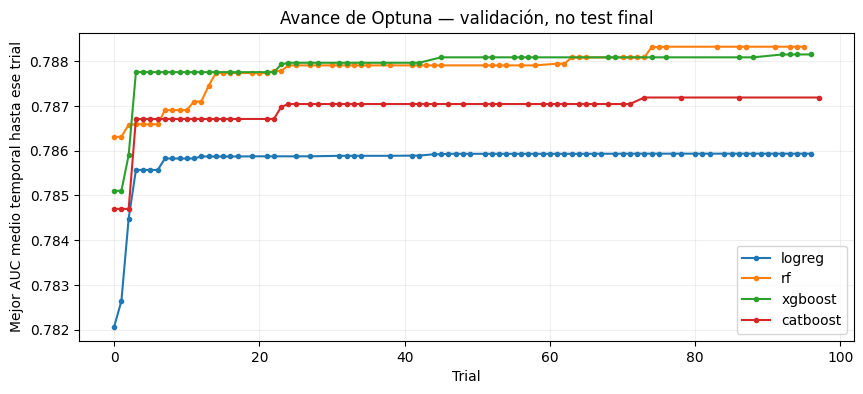

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, study in studies.items():
    completos = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if completos:
        ax.plot([t.number for t in completos], np.maximum.accumulate([t.value for t in completos]),
                marker=".", label=name)
ax.set(xlabel="Trial", ylabel="Mejor AUC medio temporal hasta ese trial",
       title="Avance de Optuna — validación, no test final")
if studies:
    ax.legend()
ax.grid(alpha=0.2)
plt.show()

In [13]:
detalle = []
for name, study in studies.items():
    if not any(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials):
        continue
    for fold, metricas in enumerate(study.best_trial.user_attrs["fold_metrics"]):
        detalle.append({"modelo": name, "trial": study.best_trial.number, "fold": fold,
                        **{k: v for k, v in metricas.items() if k != "monthly_auc"}})
display(pd.DataFrame(detalle))

,modelo,trial,fold,auc,average_precision,lift10,recall_at_05,n_features
0,logreg,71,0,0.783254,0.616830,1.977265,0.754258,42
1,logreg,71,1,0.791425,0.562034,2.329684,0.733333,42
2,logreg,71,2,0.778714,0.536579,2.225806,0.741935,42
3,logreg,71,3,0.790348,0.655782,2.366540,0.753666,42
4,rf,76,0,0.781716,0.604930,2.026086,0.345499,42
5,rf,76,1,0.795571,0.547737,2.259088,0.322807,42
6,rf,76,2,0.778452,0.535861,2.258065,0.377419,42
7,rf,76,3,0.797566,0.664139,2.455286,0.428152,42
8,xgboost,92,0,0.784042,0.602764,2.001675,0.372263,42
9,xgboost,92,1,0.794129,0.540265,2.223789,0.368421,42


## 8. Entrenar o reanudar desde el notebook

Esta celda contiene el bucle de entrenamiento real: prepara los folds, abre SQLite,
alterna un trial por algoritmo y exporta las mejoras. **No invoca `run()` ni un
comando externo.** Por defecto se omite para poder ejecutar el notebook completo
sin competir con el proceso activo.

Si se modifica la metodología, usar otro directorio `OUT`. Para reanudar los estudios
ya creados, mantener las definiciones originales y guardar el notebook antes de ejecutar.
Se verifica que las funciones guardadas coincidan con el protocolo del backend validado.
El bloqueo se libera al acabar o interrumpir el kernel. `STOP` permite salir entre trials.

In [14]:
if not EJECUTAR_ENTRENAMIENTO:
    print("Modo consulta. El proceso de segundo plano puede seguir entrenando.")
else:
    OUT.mkdir(parents=True, exist_ok=True)
    backend = ROOT / "scripts/temporal_optuna.py"
    # Este notebook es una interfaz ejecutable del mismo protocolo validado.
    # Evita mezclar cambios de funciones guardadas con un estudio existente.
    notebook_path = ROOT / "05_modelling/06_optuna_validacion_temporal.ipynb"
    notebook_json = json.loads(notebook_path.read_text())
    nb_source = "\n".join("".join(c["source"]) for c in notebook_json["cells"] if c["cell_type"] == "code")
    backend_defs = {n.name: ast.dump(n, include_attributes=False) for n in ast.parse(backend.read_text()).body
                    if isinstance(n, ast.FunctionDef)}
    nb_defs = {n.name: ast.dump(n, include_attributes=False) for n in ast.parse(nb_source).body
               if isinstance(n, ast.FunctionDef)}
    different = [name for name, definition in nb_defs.items() if backend_defs.get(name) != definition]
    if different:
        raise ValueError(f"Funciones modificadas: {different}. Actualizar y validar el protocolo antes de reanudar.")
    protocol = {"version": 1, "code_sha256": digest(backend),
                "raw_sha256": digest(PROC / "churn_dataset.csv"),
                "train_rows": len(train), "train_end": str(train.mes_obs.max().date()),
                "folds": 4, "validation_months": 4, "gap_months": 6,
                "objective": "unweighted mean validation block ROC AUC",
                "excluded_master_columns": MASTER, "seed": 42, "threads": THREADS,
                "packages": {p: importlib.metadata.version(p) for p in
                             ["numpy", "pandas", "scikit-learn", "optuna", "xgboost", "catboost"]}}
    with (OUT / "runner.lock").open("w") as lock:
        # Si el proceso tmux sigue activo, esta línea falla sin tocar sus trials.
        fcntl.flock(lock, fcntl.LOCK_EX | fcntl.LOCK_NB)
        manifest = OUT / "protocol.json"
        if manifest.exists() and json.loads(manifest.read_text()) != protocol:
            raise ValueError("Cambió el protocolo/datos: usar otro directorio OUT")
        write_json(manifest, protocol)
        cache = OUT / "folds.joblib"
        if cache.exists():
            folds = joblib.load(cache)
        else:
            folds = prepare(train, THREADS)
            joblib.dump(folds, cache)
            write_json(OUT / "folds.json", [f["info"] for f in folds])
        storage = optuna.storages.RDBStorage(url=f"sqlite:///{OUT / 'studies.sqlite3'}",
                                           engine_kwargs={"connect_args": {"timeout": 60}})
        studies = {}
        for name in MODELS:
            study = optuna.create_study(storage=storage, study_name=f"temporal_v1_{name}",
                                       direction="maximize", load_if_exists=True,
                                       sampler=optuna.samplers.TPESampler(seed=42),
                                       pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1))
            for trial in study.get_trials(states=(optuna.trial.TrialState.RUNNING,)):
                study.tell(trial.number, state=optuna.trial.TrialState.FAIL)
            studies[name] = study
        seguir = True
        while seguir and not (OUT / "STOP").exists():
            seguir = False
            for name, study in studies.items():
                if (OUT / "STOP").exists():
                    break
                if sum(t.state.is_finished() for t in study.trials) >= N_TRIALS:
                    continue
                seguir = True
                study.sampler = optuna.samplers.TPESampler(seed=42 + len(study.trials))
                prev = study.best_trial.number if any(t.state == optuna.trial.TrialState.COMPLETE
                                                     for t in study.trials) else None
                study.optimize(lambda t: objective(t, name, folds, THREADS), n_trials=1)
                if prev != study.best_trial.number:
                    export_best(study, name, train, THREADS, OUT)
                study.trials_dataframe().to_csv(OUT / f"{name}_trials.csv", index=False)
                print(name, len(study.trials), "/", N_TRIALS, "mejor AUC:", study.best_value)
        print("Entrenamiento terminado o pausado. Reejecutar sección 7 para actualizar tablas.")

Modo consulta. El proceso de segundo plano puede seguir entrenando.


## 9. Qué concluir al terminar

Comparar el AUC medio junto con el comportamiento por período y el lift operativo.
No comparar directamente este AUC temporal con el AUC del único OOT antiguo:
corresponden a períodos, protocolo y variables distintos.

Los mejores trials están seleccionados sobre estas validaciones. Para afirmar
mejora en despliegue se necesita una evaluación final en datos nuevos y después
un piloto de retención con costos reales. El resultado de Optuna es un candidato,
no una prueba de rentabilidad ni del techo teórico del problema.